#exploring data and analysing it

In [38]:
import os
import numpy as np
import pandas as pd

df = pd.read_csv("../data/raw/metricses.csv")
df.head(5)

,timestamp,cpu,memory,latency,error_rate
0,2016-01-01 14:08:00,43.622600,74.541858,169.606237,1.850059
1,2016-01-01 08:26:00,44.076061,70.445812,347.454721,2.322975
2,2016-01-01 09:34:00,58.294056,66.996450,331.039655,0.729939
3,2016-01-01 02:19:00,37.691357,70.517591,126.623737,1.732359
4,2016-01-01 02:32:00,43.199753,50.415574,201.044324,0.000000


In [39]:
df.info()
print("*"*20)
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   timestamp   1000 non-null   str    
 1   cpu         951 non-null    float64
 2   memory      1000 non-null   float64
 3   latency     950 non-null    float64
 4   error_rate  1000 non-null   float64
dtypes: float64(4), str(1)
memory usage: 57.7 KB
********************


(1000, 5)

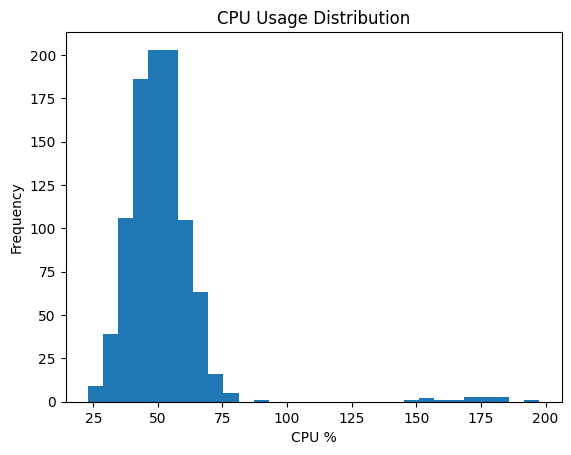

In [40]:
import matplotlib.pyplot as plt
plt.hist(df["cpu"],bins=30)
plt.title("CPU Usage Distribution")
plt.xlabel("CPU %")
plt.ylabel("Frequency")
plt.show()

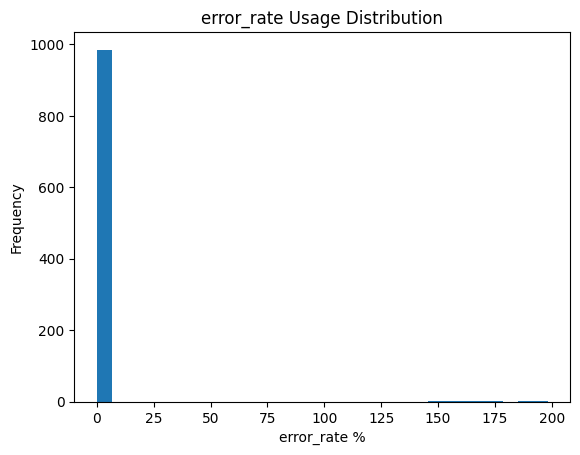

In [41]:
plt.hist(df["error_rate"],bins=30)
plt.title("error_rate Usage Distribution")
plt.xlabel("error_rate %")
plt.ylabel("Frequency")
plt.show()

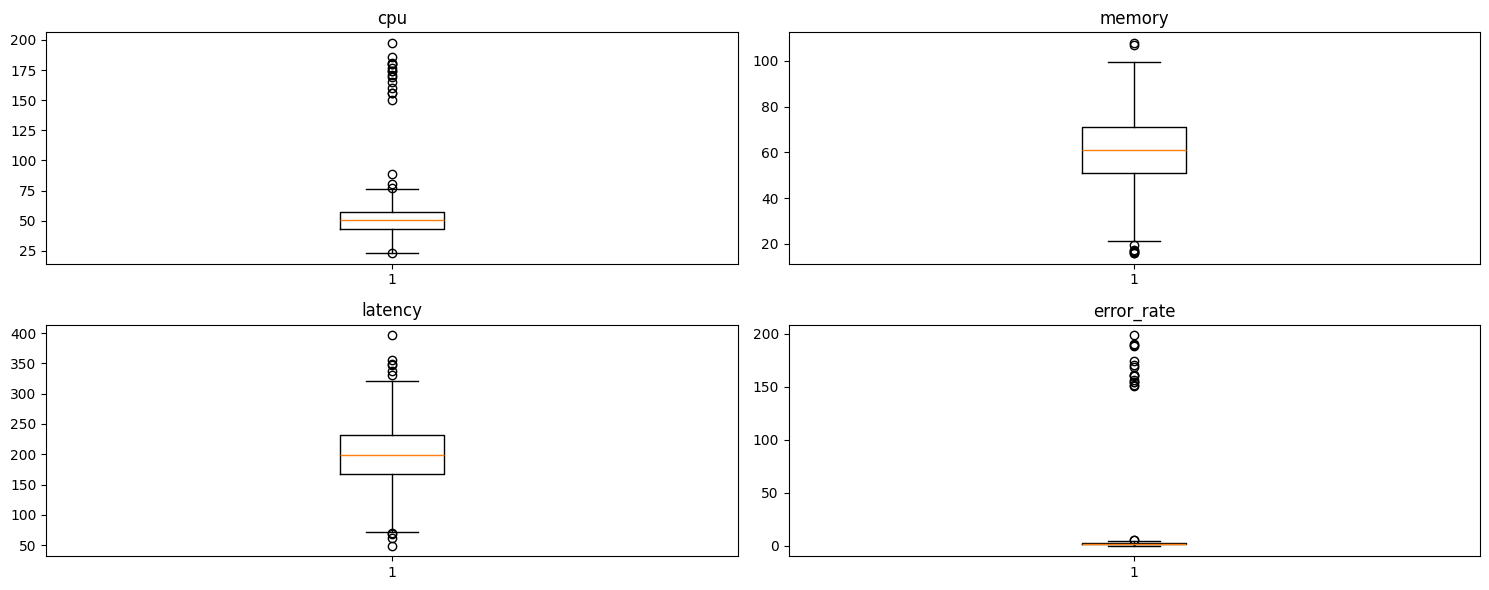

In [42]:
numeric_cols = df.select_dtypes(include="number").columns

fig, axes = plt.subplots(nrows=2, ncols=(len(numeric_cols)+1)//2, figsize=(15, 6))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

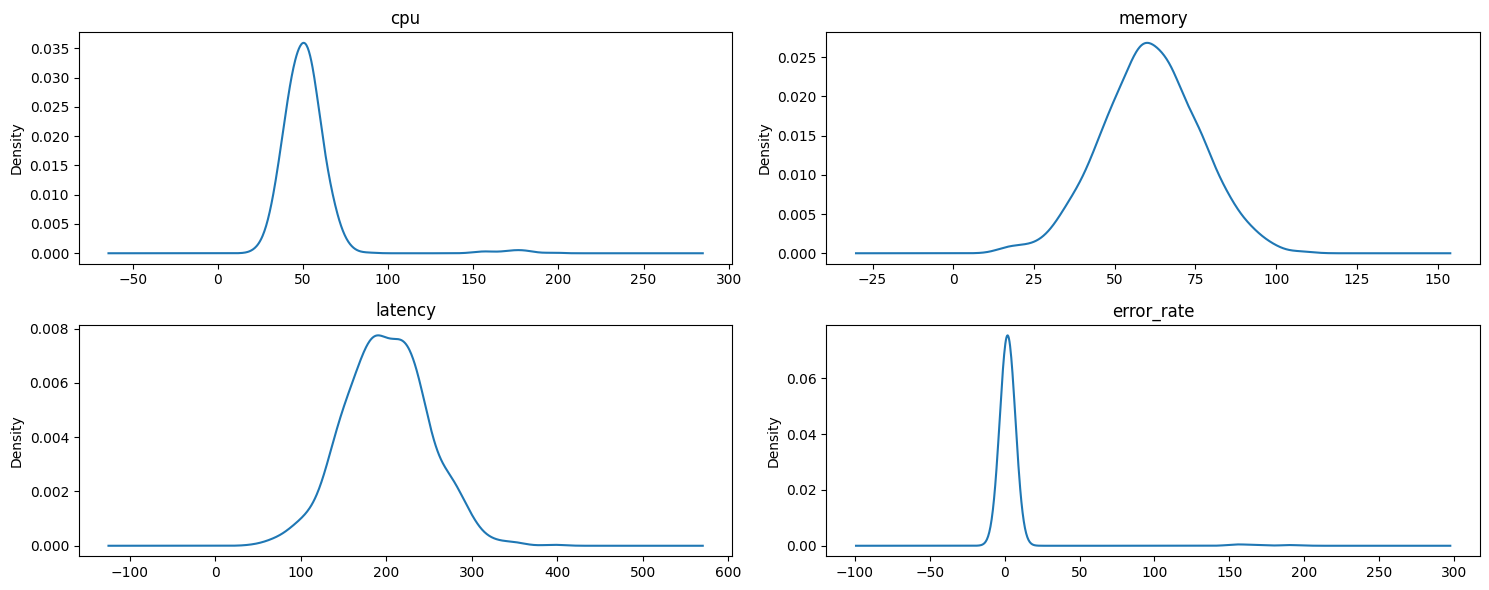

In [43]:
fig, axes = plt.subplots(nrows=2, ncols=(len(numeric_cols)+1)//2, figsize=(15, 6))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].plot.kde(ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

Confirm that directly instead of guessing from the plot:

In [44]:
print(df["error_rate"].min())
print(df["error_rate"].max())

0.0
198.30107295651044


In [45]:
df.describe()

,cpu,memory,latency,error_rate
count,951.000000,1000.000000,950.000000,1000.000000
mean,52.060400,61.062544,200.232872,4.487408
std,18.090876,14.961816,48.687838,20.364711
min,23.031134,15.894170,49.024392,0.000000
25%,43.482818,50.906375,167.977894,1.268018
50%,50.469806,60.946157,199.604459,2.029245
75%,56.840022,70.933233,232.371778,2.712420
max,197.525178,107.896614,396.311885,198.301073


In [46]:


numeric_df = df.select_dtypes(include="number")

q1 = numeric_df.quantile(0.25)
q3 = numeric_df.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers_mask = (numeric_df < lower_bound) | (numeric_df > upper_bound)
outlier_counts = outliers_mask.sum()

print(outlier_counts)

cpu           19
memory         8
latency       10
error_rate    17
dtype: int64


In [47]:
df.isnull().sum()

timestamp      0
cpu           49
memory         0
latency       50
error_rate     0
dtype: int64

In [52]:
df["cpu"] = df["cpu"].fillna(df["cpu"].mean())
df["latency"] = df["latency"].fillna(df["latency"].median())
print(df["cpu"])
print(df["latency"])

0      43.622600
1      44.076061
2      58.294056
3      37.691357
4      43.199753
         ...    
995    41.532063
996    62.669111
997    56.159356
998    57.818229
999    57.569886
Name: cpu, Length: 1000, dtype: float64
0      169.606237
1      347.454721
2      331.039655
3      126.623737
4      201.044324
          ...    
995    178.537779
996    244.344370
997    193.275161
998    274.493172
999    106.172365
Name: latency, Length: 1000, dtype: float64


In [57]:
print(df[df["cpu"] > 100])
print("="*70)
print(df[df["latency"] >200])

               timestamp         cpu      memory     latency  error_rate
94   2016-01-01 13:25:00  197.525178   36.237961  111.187683  154.003170
102  2016-01-01 15:57:00  185.734804  107.066228  188.172236  154.238308
174  2016-01-01 05:13:00  164.946308   68.367155  224.887154  188.573667
235  2016-01-01 06:02:00  181.128770   61.793706  199.604459  151.291949
360  2016-01-01 09:43:00  176.408886   60.925198  261.178444  160.884990
419  2016-01-01 00:00:00  171.218601   80.990332  166.241086  150.498462
472  2016-01-01 00:03:00  169.180452   50.295948  184.601924  173.722659
566  2016-01-01 13:47:00  174.124653   81.163986  196.899800  168.591839
597  2016-01-01 04:53:00  159.742025   72.577362  159.586714  189.023557
639  2016-01-01 01:07:00  179.624674   77.412402  193.286042  156.531719
682  2016-01-01 15:52:00  155.853221   46.414015  223.333549  170.540820
764  2016-01-01 01:00:00  174.566522   71.575481  242.544898  160.058762
806  2016-01-01 02:24:00  156.343641   57.403923  1

In [59]:
df["latency"].max()
df[df["latency"] == df["latency"].max()]

,timestamp,cpu,memory,latency,error_rate
299,2016-01-01 14:55:00,56.487099,54.449835,396.311885,3.001632


In [60]:
df.corr(numeric_only=True)

,cpu,memory,latency,error_rate
cpu,1.000000,0.035193,-0.007555,0.829202
memory,0.035193,1.000000,-0.015658,0.058401
latency,-0.007555,-0.015658,1.000000,-0.022274
error_rate,0.829202,0.058401,-0.022274,1.000000


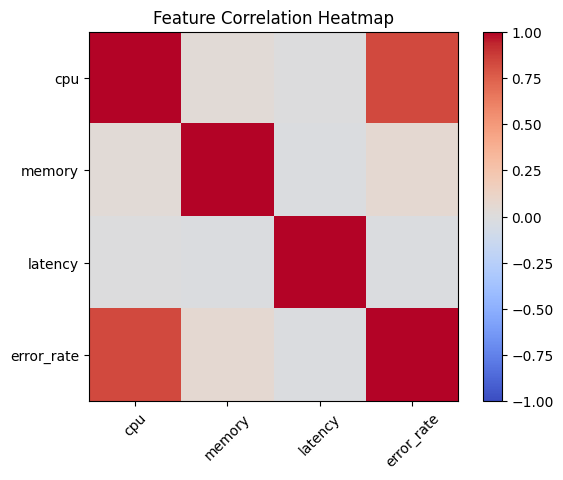

In [61]:


plt.imshow(df[numeric_cols].corr(), cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Feature Correlation Heatmap")
plt.show()